In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

In [3]:
df = pd.read_csv("/content/app_user_behavior_dataset.csv")

In [4]:
print(df.head())

   user_id  age  gender    country device_type  app_version  \
0   100000   56  Female      India         iOS          2.1   
1   100001   46    Male         UK         iOS          1.0   
2   100002   32  Female         UK         iOS          1.2   
3   100003   25    Male      India     Android          2.0   
4   100004   38    Male  Australia     Android          1.0   

   sessions_per_week  avg_session_duration_min  daily_active_minutes  \
0                  5                      3.41                 52.71   
1                  8                     24.44                 42.03   
2                 12                      5.34                 76.69   
3                  5                      3.98                 65.38   
4                 10                     12.85                 57.06   

   feature_clicks_per_session  ...  days_since_last_login  subscription_type  \
0                          13  ...                     20              Basic   
1                           

In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   user_id                        50000 non-null  int64  
 1   age                            50000 non-null  int64  
 2   gender                         50000 non-null  object 
 3   country                        50000 non-null  object 
 4   device_type                    50000 non-null  object 
 5   app_version                    50000 non-null  float64
 6   sessions_per_week              50000 non-null  int64  
 7   avg_session_duration_min       50000 non-null  float64
 8   daily_active_minutes           50000 non-null  float64
 9   feature_clicks_per_session     50000 non-null  int64  
 10  notifications_opened_per_week  50000 non-null  int64  
 11  in_app_search_count            50000 non-null  int64  
 12  pages_viewed_per_session       50000 non-null 

In [6]:
print(df.describe())

             user_id           age   app_version  sessions_per_week  \
count   50000.000000  50000.000000  50000.000000       50000.000000   
mean   124999.500000     38.513040      1.476126           7.999680   
std     14433.901067     12.094948      0.470158           2.829438   
min    100000.000000     18.000000      1.000000           0.000000   
25%    112499.750000     28.000000      1.100000           6.000000   
50%    124999.500000     39.000000      1.200000           8.000000   
75%    137499.250000     49.000000      2.000000          10.000000   
max    149999.000000     59.000000      2.100000          26.000000   

       avg_session_duration_min  daily_active_minutes  \
count              50000.000000          50000.000000   
mean                  13.149842             45.164537   
std                    8.946944             19.505118   
min                    0.060000              5.000000   
25%                    6.570000             31.650000   
50%               

In [7]:
df = df.drop_duplicates()

In [8]:
df = df.dropna()
df = df.reset_index(drop=True)

In [9]:
print(df.isnull().sum())

user_id                          0
age                              0
gender                           0
country                          0
device_type                      0
app_version                      0
sessions_per_week                0
avg_session_duration_min         0
daily_active_minutes             0
feature_clicks_per_session       0
notifications_opened_per_week    0
in_app_search_count              0
pages_viewed_per_session         0
crash_events_last_30_days        0
support_tickets_raised           0
days_since_last_login            0
subscription_type                0
ads_clicked_last_30_days         0
content_downloads                0
social_shares                    0
rating_given                     0
churn_risk_score                 0
engagement_score                 0
account_age_days                 0
marketing_source                 0
dtype: int64


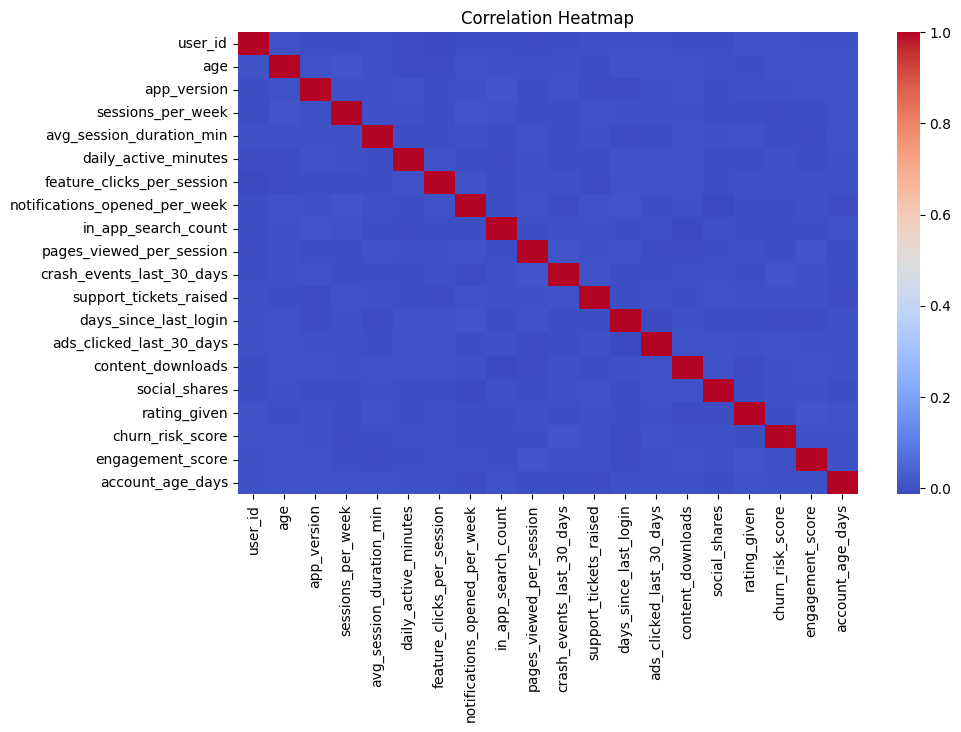

In [10]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [11]:
features = [
    'sessions_per_week',
    'avg_session_duration_min',
    'daily_active_minutes',
    'feature_clicks_per_session',
    'engagement_score'
]

X = df[features]

In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

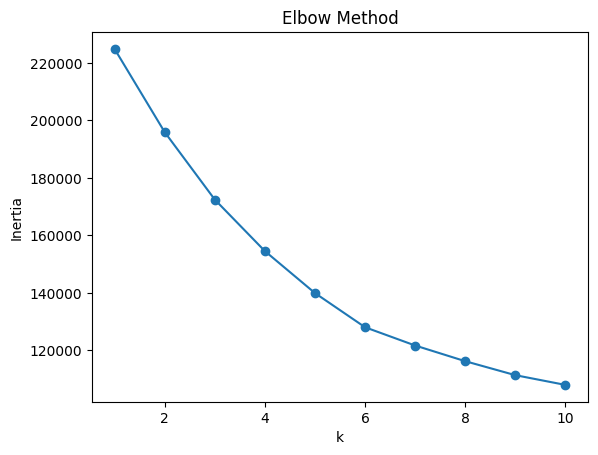

In [13]:
inertia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.show()

In [14]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

In [15]:
dbscan = DBSCAN(eps=1.5, min_samples=10)
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

In [16]:
sample_df = df.sample(n=5000, random_state=42)

X_sample = sample_df[features]

scaler = StandardScaler()
X_scaled_sample = scaler.fit_transform(X_sample)

from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=3)
sample_df['agg_cluster'] = agg.fit_predict(X_scaled_sample)

print(sample_df['agg_cluster'].value_counts())

agg_cluster
0    2346
1    2008
2     646
Name: count, dtype: int64


In [17]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [18]:
kmeans_profile = df.groupby('kmeans_cluster')[features].mean()
print("KMeans:\n", kmeans_profile)

dbscan_profile = df.groupby('dbscan_cluster')[features].mean()
print("DBSCAN:\n", dbscan_profile)

agglo_profile = sample_df.groupby('agg_cluster')[features].mean()
print("Agglomerative:\n", agglo_profile)

KMeans:
                 sessions_per_week  avg_session_duration_min  \
kmeans_cluster                                                
0                        8.062047                 27.139252   
1                        8.651276                  9.705099   
2                        7.336946                  9.738599   

                daily_active_minutes  feature_clicks_per_session  \
kmeans_cluster                                                     
0                          44.006355                   11.795177   
1                          58.081799                   10.788795   
2                          32.667163                   13.347453   

                engagement_score  
kmeans_cluster                    
0                      64.623725  
1                      60.618117  
2                      69.448238  
DBSCAN:
                 sessions_per_week  avg_session_duration_min  \
dbscan_cluster                                                
-1                      

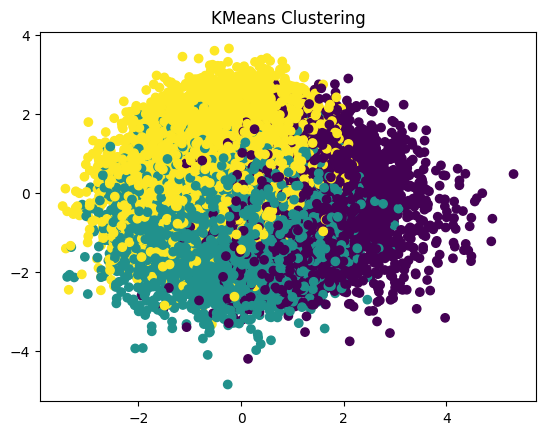

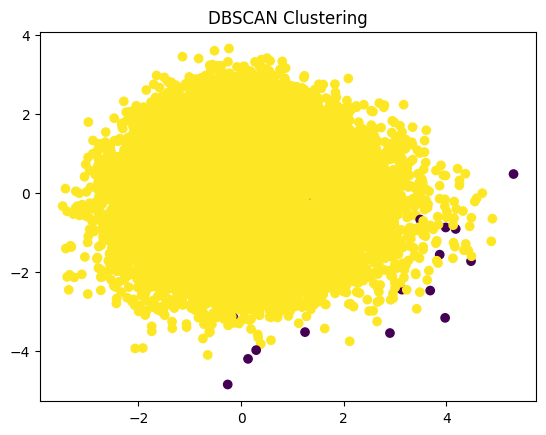

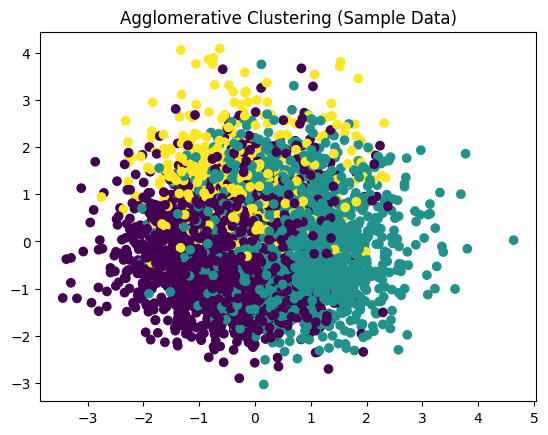

In [19]:
plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['kmeans_cluster'])
plt.title("KMeans Clustering")
plt.show()

# Visualize DBSCAN Clusters
plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['dbscan_cluster'])
plt.title("DBSCAN Clustering")
plt.show()

# Visualize Agglomerative Clusters (Sample Data)
pca_sample = PCA(n_components=2)
X_pca_sample = pca_sample.fit_transform(X_scaled_sample)

plt.figure()
plt.scatter(X_pca_sample[:,0], X_pca_sample[:,1], c=sample_df['agg_cluster'])
plt.title("Agglomerative Clustering (Sample Data)")
plt.show()

In [20]:
print("KMeans Score:", silhouette_score(X_scaled, df['kmeans_cluster']))

try:
    print("DBSCAN Score:", silhouette_score(X_scaled, df['dbscan_cluster']))
except:
    print("DBSCAN Score: Not valid")

KMeans Score: 0.13860942239701107
DBSCAN Score: 0.5133416528708382


In [21]:
print("Agglomerative Score (Sample):", silhouette_score(X_scaled_sample,
sample_df['agg_cluster']))

Agglomerative Score (Sample): 0.09676715493830472


In [22]:
print(sample_df.columns)

Index(['user_id', 'age', 'gender', 'country', 'device_type', 'app_version',
       'sessions_per_week', 'avg_session_duration_min', 'daily_active_minutes',
       'feature_clicks_per_session', 'notifications_opened_per_week',
       'in_app_search_count', 'pages_viewed_per_session',
       'crash_events_last_30_days', 'support_tickets_raised',
       'days_since_last_login', 'subscription_type',
       'ads_clicked_last_30_days', 'content_downloads', 'social_shares',
       'rating_given', 'churn_risk_score', 'engagement_score',
       'account_age_days', 'marketing_source', 'kmeans_cluster',
       'dbscan_cluster', 'agg_cluster'],
      dtype='object')


In [23]:
print(df.columns)

Index(['user_id', 'age', 'gender', 'country', 'device_type', 'app_version',
       'sessions_per_week', 'avg_session_duration_min', 'daily_active_minutes',
       'feature_clicks_per_session', 'notifications_opened_per_week',
       'in_app_search_count', 'pages_viewed_per_session',
       'crash_events_last_30_days', 'support_tickets_raised',
       'days_since_last_login', 'subscription_type',
       'ads_clicked_last_30_days', 'content_downloads', 'social_shares',
       'rating_given', 'churn_risk_score', 'engagement_score',
       'account_age_days', 'marketing_source', 'kmeans_cluster',
       'dbscan_cluster'],
      dtype='object')


In [24]:
kmeans_profile = df.groupby('kmeans_cluster')[features].mean()
print(kmeans_profile)

for i in kmeans_profile.index:
    print(f"\nCluster {i} Analysis:")

    if kmeans_profile.loc[i, 'engagement_score'] > df['engagement_score'].mean():
        print("→ High Engagement Users → Focus on Loyalty Programs")
    else:
        print("→ Low Engagement Users → Focus on Retention Strategies")

                sessions_per_week  avg_session_duration_min  \
kmeans_cluster                                                
0                        8.062047                 27.139252   
1                        8.651276                  9.705099   
2                        7.336946                  9.738599   

                daily_active_minutes  feature_clicks_per_session  \
kmeans_cluster                                                     
0                          44.006355                   11.795177   
1                          58.081799                   10.788795   
2                          32.667163                   13.347453   

                engagement_score  
kmeans_cluster                    
0                      64.623725  
1                      60.618117  
2                      69.448238  

Cluster 0 Analysis:
→ Low Engagement Users → Focus on Retention Strategies

Cluster 1 Analysis:
→ Low Engagement Users → Focus on Retention Strategies

Cluster 2 Analy

In [25]:
print("\n===== DBSCAN INSIGHTS =====")

dbscan_profile = df.groupby('dbscan_cluster')[features].mean()
print(dbscan_profile)

noise_count = (df['dbscan_cluster'] == -1).sum()
print(f"\nNoise Users (Outliers): {noise_count}")

print("→ These users may be inactive / abnormal → Need special attention")


===== DBSCAN INSIGHTS =====
                sessions_per_week  avg_session_duration_min  \
dbscan_cluster                                                
-1                       10.72000                 46.694000   
 0                        8.00565                 13.123325   

                daily_active_minutes  feature_clicks_per_session  \
dbscan_cluster                                                     
-1                         56.929200                   15.200000   
 0                         45.093603                   12.013325   

                engagement_score  
dbscan_cluster                    
-1                     56.313600  
 0                     64.959545  

Noise Users (Outliers): 25
→ These users may be inactive / abnormal → Need special attention


In [26]:
print("\n===== AGGLOMERATIVE INSIGHTS =====")

agglo_profile = sample_df.groupby('agg_cluster')[features].mean()
print(agglo_profile)

for i in agglo_profile.index:
    print(f"\nCluster {i} Analysis:")

    if agglo_profile.loc[i, 'sessions_per_week'] > sample_df['sessions_per_week'].mean():
        print("→ Active Users → Target for Upselling")
    else:
        print("→ Less Active Users → Improve Engagement")


===== AGGLOMERATIVE INSIGHTS =====
             sessions_per_week  avg_session_duration_min  \
agg_cluster                                                
0                     8.055413                  9.742950   
1                     7.917829                 12.105274   
2                     8.010836                 27.209288   

             daily_active_minutes  feature_clicks_per_session  \
agg_cluster                                                     
0                       45.984953                   10.257033   
1                       43.196031                   14.369522   
2                       48.313932                   11.546440   

             engagement_score  
agg_cluster                    
0                   69.432933  
1                   58.399447  
2                   70.700046  

Cluster 0 Analysis:
→ Active Users → Target for Upselling

Cluster 1 Analysis:
→ Less Active Users → Improve Engagement

Cluster 2 Analysis:
→ Active Users → Target for Upselli

In [27]:
print("\n===== FINAL BUSINESS INSIGHTS =====")

high_users = df[df['kmeans_cluster'] == 0]
low_users = df[df['kmeans_cluster'] == 2]

print("High Value Users:", high_users.shape[0])
print("Low Engagement Users:", low_users.shape[0])

print("\n→ Action Plan:")
print("• High users → Loyalty & Rewards")
print("• Moderate users → Engagement Improvement")
print("• Low users → Retention Campaigns")


===== FINAL BUSINESS INSIGHTS =====
High Value Users: 8832
Low Engagement Users: 18083

→ Action Plan:
• High users → Loyalty & Rewards
• Moderate users → Engagement Improvement
• Low users → Retention Campaigns
